Logistic Regression pada Binary Classification Task

In [1]:
import pandas as pd
df = pd.read_csv('D:\SKLearn\SMSSpamCollection.txt', sep='\t', header=None, names=['label','sms'])
df.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [3]:
from sklearn.preprocessing import LabelBinarizer

X = df['sms'].values
y = df['label'].values

lb = LabelBinarizer()
y = lb.fit_transform(y).ravel()
lb.classes_

array(['ham', 'spam'], dtype='<U4')

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=0)

print(X_train, '\n')
print(y_train)

["No I'm good for the movie, is it ok if I leave in an hourish?"
 'If you were/are free i can give. Otherwise nalla adi entey nattil kittum'
 'Have you emigrated or something? Ok maybe 5.30 was a bit hopeful...' ...
 "For ur chance to win a £250 cash every wk TXT: ACTION to 80608. T's&C's www.movietrivia.tv custcare 08712405022, 1x150p/wk"
 'R U &SAM P IN EACHOTHER. IF WE MEET WE CAN GO 2 MY HOUSE'
 'Mm feeling sleepy. today itself i shall get that dear'] 

[0 0 0 ... 1 0 0]


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34657 stored elements and shape (4457, 7531)>
  Coords	Values
  (0, 3106)	0.30778739607068667
  (0, 4491)	0.4933198981059812
  (0, 4781)	0.2937599690543961
  (0, 3965)	0.40459749284424307
  (0, 3427)	0.6418008618863358
  (1, 2907)	0.21207121889209815
  (1, 4560)	0.42053679904641994
  (1, 818)	0.44107102567653744
  (1, 2539)	0.44107102567653744
  (1, 4579)	0.44107102567653744
  (1, 3860)	0.44107102567653744
  (2, 4781)	0.2349500626979615
  (2, 2508)	0.5133141633463273
  (2, 4299)	0.36445133334144264
  (2, 435)	0.4077104256374456
  (2, 1322)	0.34462014146959175
  (2, 3403)	0.5133141633463273
  (3, 3783)	0.3134261626040451
  (3, 3123)	0.3618429196578873
  (3, 3383)	0.3853995778343805
  (3, 1165)	0.44847242609346283
  (3, 1142)	0.6489787288715116
  (4, 3810)	1.0
  (5, 7386)	0.7984426989330436
  (5, 3736)	0.6020708068994186
  :	:
  (4454, 7016)	0.14040083857773877
  (4454, 1670)	0.21130971337962476
  (4454, 7316)	0.19497533818187

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

for pred, sms in zip(y_pred[:5], X_test[:5]):
    print(f'PRED (Predicted): {pred} - SMS: {sms}\n')

PRED (Predicted): 0 - SMS: Storming msg: Wen u lift d phne, u say "HELLO" Do u knw wt is d real meaning of HELLO?? . . . It's d name of a girl..! . . . Yes.. And u knw who is dat girl?? "Margaret Hello" She is d girlfrnd f Grahmbell who invnted telphone... . . . . Moral:One can 4get d name of a person, bt not his girlfrnd... G o o d n i g h t . . .@

PRED (Predicted): 0 - SMS: <Forwarded from 448712404000>Please CALL 08712404000 immediately as there is an urgent message waiting for you.

PRED (Predicted): 0 - SMS: And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed

PRED (Predicted): 0 - SMS: Sir Goodmorning, Once free call me.

PRED (Predicted): 0 - SMS: All will come alive.better correct any good looking figure there itself..



In [7]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[954,   1],
       [ 36, 124]])

In [8]:
tn, fp, fn, tp = matrix.ravel()

print(f'TN: {tn}')
print(f'FP: {fp}')
print(f'FN: {fn}')
print(f'TP: {tp}')

TN: 954
FP: 1
FN: 36
TP: 124


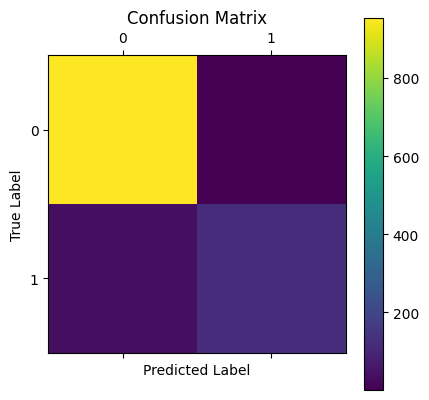

In [9]:
import matplotlib.pyplot as plt

plt.matshow(matrix)
plt.colorbar()

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9668161434977578

In [11]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.992

In [12]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.775

In [13]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)    

0.8701754385964913

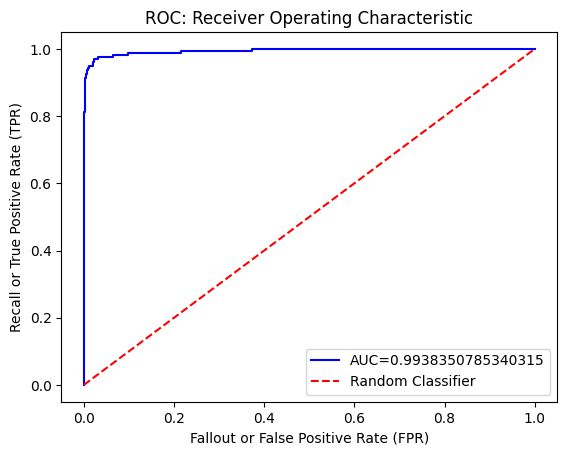

In [14]:
from sklearn.metrics import roc_curve, auc

prob_estimates = model.predict_proba(X_test_tfidf)
fpr, tpr, threshold = roc_curve(y_test, prob_estimates[:, 1])
nilai_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, 'b', label=f'AUC={nilai_auc}')
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')  #Garis diagonal untuk referensi

plt.title('ROC: Receiver Operating Characteristic')
plt.xlabel('Fallout or False Positive Rate (FPR)')
plt.ylabel('Recall or True Positive Rate (TPR)')
plt.legend()
plt.show()